In [1]:
from getdist import loadMCSamples, plots
import getdist
import numpy as np
import matplotlib.pyplot as plt
import yaml


In [ ]:
import os
dirname = os.getcwd()
print(dirname)
if os.getcwd().endswith("cosmosis-standard-library" + os.path.sep + "examples_rose" + os.path.sep + "notebooks"):
    print("Switching to directory cosmosis-standard-library")
    os.chdir(os.path.pardir)
    os.chdir(os.path.pardir)

/Users/s2265800/Desktop/Work/cosmosis_stuff/cosmosis-standard-library/examples_rose/plotting_scripts
Switching to directory cosmosis-standard-library


In [3]:
dirname = os.getcwd()
print(dirname)

/Users/s2265800/Desktop/Work/cosmosis_stuff/cosmosis-standard-library


In [ ]:
# Load parameter configuration files
# params_names.yaml contains the mapping from parameter names to LaTeX labels

with open("examples_rose/notebooks/fiducials_cmb_w0wa_full.yaml", "r") as file:
    fiducial_dic = yaml.safe_load(file)
    fiducials = {k: v['p0'] for k, v in fiducial_dic.items()}
    params_dic = {k: v['latex'] for k, v in fiducial_dic.items()}
    ranges = {k: v['range'] for k, v in fiducial_dic.items()}

In [5]:
def read_first_header_line(file_path):
    """
    Extract parameter names from the first header line of a chain file.
    
    The first header line contains the parameter names.

    Parameters:
    -----------
    file_path : str
        Path to the MCMC chain file
        
    Returns:
    --------
    list
        List of parameter names extracted from the header, or empty list if no header found
        
    """
    with open(file_path, 'r', encoding='utf-8') as file:
        first_line = file.readline()
        
    # Extract the first header line (remove '#' and whitespace, then split)
    if first_line:
        first_header = first_line.strip('#').strip()
        if first_header:
            #return [param.split('--')[-1] if '--' in param else param for param in first_header.split()]
            return [param for param in first_header.split()]
    return []

In [6]:
file_paths = [ 
'output/rose_desi_pantheon/chain_rose_desi_pantheon_tempering_0.05_iteration_1.txt',
'output/rose_desi_pantheon/chain_rose_desi_pantheon_tempering_0.2875_iteration_2.txt',
'output/rose_desi_pantheon/chain_rose_desi_pantheon_tempering_0.525_iteration_3.txt',
'output/rose_desi_pantheon/chain_rose_desi_pantheon_tempering_0.7625_iteration_4.txt',
'output/rose_desi_pantheon/chain_rose_desi_pantheon.txt',
'output/nautilus_desi_pantheon/chain_nautilus_desi_pantheon.txt'
 ]  

In [7]:
# Legend labels for each chain (LaTeX formatting supported)
legend_labels = [
'iteration 1',
'iteration 2',
'iteration 3',
'iteration 4',
'iteration 5',
'exact'
]

In [8]:

# =============================================================================
# DATA LOADING SECTION
# =============================================================================

n_samples = len(file_paths)
chains_info = {}

# Load each MCMC chain file
for i in range(n_samples):
    file_path = file_paths[i]  
    
    # Load numerical data from chain file
    chain = np.genfromtxt(file_path)
    
    # Extract parameter names from header
    chain_pars = read_first_header_line(file_path)
    
    # Remove last two columns (typically log-likelihood and weight)
    chain_pars = chain_pars[:-4] if i != n_samples-1  else chain_pars[:-3]
    print(chain_pars)
    # Store chain data and parameter names
    chains_info[i] = {}
    chains_info[i]['chain'] = chain[:,:len(chain_pars)]
    #assuming that the last chain is done with Nautilus while the others are done with emcee
    weights = np.exp(chain[:, -3]) if i == (n_samples-1) else np.exp(chain[:, -1]) 
    chains_info[i]['weights'] = weights
    chains_info[i]['pars'] = chain_pars



['cosmological_parameters--omch2', 'cosmological_parameters--ombh2', 'cosmological_parameters--h0', 'cosmological_parameters--w', 'cosmological_parameters--wa', 'supernova_params--m']
['cosmological_parameters--omch2', 'cosmological_parameters--ombh2', 'cosmological_parameters--h0', 'cosmological_parameters--w', 'cosmological_parameters--wa', 'supernova_params--m']
['cosmological_parameters--omch2', 'cosmological_parameters--ombh2', 'cosmological_parameters--h0', 'cosmological_parameters--w', 'cosmological_parameters--wa', 'supernova_params--m']
['cosmological_parameters--omch2', 'cosmological_parameters--ombh2', 'cosmological_parameters--h0', 'cosmological_parameters--w', 'cosmological_parameters--wa', 'supernova_params--m']
['cosmological_parameters--omch2', 'cosmological_parameters--ombh2', 'cosmological_parameters--h0', 'cosmological_parameters--w', 'cosmological_parameters--wa', 'supernova_params--m']
['cosmological_parameters--omch2', 'cosmological_parameters--ombh2', 'cosmologic

In [9]:
# =============================================================================
# GETDIST SAMPLE PREPARATION
# =============================================================================

samples = []    
for i in range(n_samples):
    # Create GetDist MCSamples object for each chain
    if i == n_samples-1 or i == n_samples-2:
        samples.append(
            getdist.MCSamples(
                # Sample data (excluding log-likelihood and weight columns)
                samples = chains_info[i]['chain'][:,:len(chains_info[i]['pars'])],
                # Parameter names
                names = [i for i in chains_info[i]['pars']],
                # Sample weights (exponential of log-likelihood)
                weights=chains_info[i]['weights'],
                # LaTeX labels for parameters (from params_dic)
                labels = [params_dic[p] for p in chains_info[i]['pars']],
                # Parameter ranges for plotting
                #ranges = ranges
            ) 
            )
    else:
        samples.append(
            getdist.MCSamples(
                # Sample data (excluding log-likelihood and weight columns)
                samples = chains_info[i]['chain'][:,:len(chains_info[i]['pars'])],
                # Parameter names
                names = [i for i in chains_info[i]['pars']],
                # Sample weights (exponential of log-likelihood)
                weights=chains_info[i]['weights'],
                # LaTeX labels for parameters (from params_dic)
                labels = [params_dic[p] for p in chains_info[i]['pars']],
                # Smoothing settings for 1D and 2D distributions
                settings={'smooth_scale_2D':0.35, 'smooth_scale_1D':0.35},
                #settings={'smooth_scale_2D':0.25, 'smooth_scale_1D':0.25},
                # Parameter ranges for plotting
                #ranges = ranges
            ) 
            )

    # Get parameter object (unused but kept for compatibility)
    p = samples[i].getParams() 

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


In [10]:
# =============================================================================
# PLOT CONFIGURATION
# =============================================================================

# Select parameters to plot (modify as needed)
#ModelPars = chains_info[0]['pars']
# Custom parameter selection - take first 5 parameters plus sigma0 and mu0
ModelPars = chains_info[0]['pars'][:8]

# Set up plotting style and colors
import seaborn as sns
sns.set_theme(style="ticks")
colors = sns.color_palette("Set2")  # Use seaborn Set2 color palette
#colors = ['#FF69B4', '#EE1289', '#CD1076', '#8B0A50', '#8B4789', '#8B2252']
# Configure LaTeX rendering for publication-quality plots
from matplotlib import rc
rc('text', usetex=True)  # Enable LaTeX text rendering
rc('font',**{'family':'serif','serif':['Times']})  # Use Times font

# Create GetDist subplot plotter
g = getdist.plots.getSubplotPlotter(subplot_size=1.3) #5

# Configure plot appearance settings
plt.rcParams.update({'font.size':16})
g.settings.legend_fontsize=32      # Legend text size
g.settings.axes_fontsize=20        # Axis tick labels size  
g.settings.axes_labelsize=24       # Axis labels size
g.settings.linewidth=4             # Contour line width
g.settings.figure_legend_frame = False  # Remove legend frame



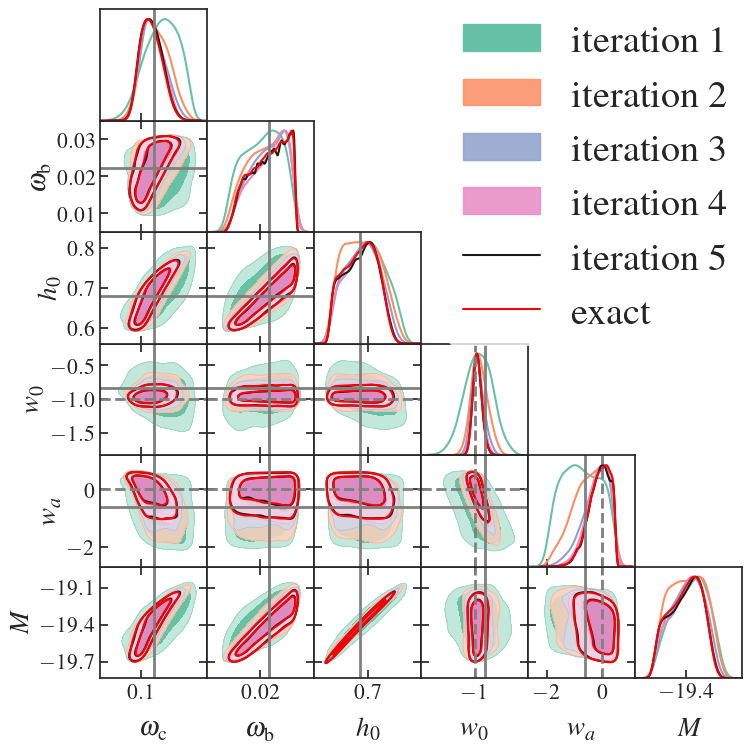

In [11]:
# =============================================================================
# CREATE TRIANGLE PLOT
# =============================================================================

# Generate the main triangle (corner) plot
g.triangle_plot(
    samples,                          # List of MCSamples objects
    ModelPars,                        # Parameters to include in plot
    legend_labels = legend_labels,    # Labels for legend
    legend_loc = 'upper right',       # Legend position
    # Filled contour styling for each sample
    contour_args = [
        {'filled':True, 'color': colors[0]}, 
        {'filled':True, 'color': colors[1], 'ls': '-'}, 
        {'filled':True, 'color': colors[2], 'ls': '-'},
        {'filled':True, 'color': colors[3], 'ls': '-'},  
        {'filled':False, 'color': 'k', 'ls': '-'},  
        {'filled':False, 'color': 'red', 'ls': '-'},  
        {'filled':True, 'color': colors[4], 'ls': '-'},  
        {'filled':True, 'color': colors[5], 'ls': '-'}
    ], 
    # 1D marginalized distribution styling
    line_args=[
        {'color': colors[0], 'ls': '-'}, 
        {'color': colors[1], 'ls': '-'}, 
        {'color': colors[2], 'ls': '-'}, 
        {'color': colors[3], 'ls': '-'}, 
        {'color': 'k', 'ls': '-'}, 
        {'color': 'red', 'ls': '-'}, 
        {'color': colors[4], 'ls': '-'}, 
        {'color': colors[5], 'ls': '-'}
    ]
)

# =============================================================================
# ADD FIDUCIAL VALUES AND THEORETICAL RELATIONS
# =============================================================================



# Add fiducial values as gray lines if available
if fiducials != None:
    for i in range(len(ModelPars)):
        for j in range(i+1):
            ax = g.subplots[i,j]
            # Add horizontal line for fiducial value of y-parameter (for 2D plots)
            if i != j and ModelPars[i] in fiducials and fiducials[ModelPars[i]] != None:
                ax.axhline(fiducials[ModelPars[i]], lw=2., color='tab:gray')
                if ModelPars[i] == 'cosmological_parameters--w':
                    ax.axhline(-1.,  lw=2., color='tab:gray', linestyle='--')
                if ModelPars[i] == 'cosmological_parameters--wa':
                    ax.axhline(0., lw=2., color='tab:gray', linestyle='--')
            
            # Add vertical line for fiducial value of x-parameter
            if ModelPars[j] in fiducials and fiducials[ModelPars[j]] != None:
                ax.axvline(fiducials[ModelPars[j]], lw=2., color='tab:gray')
                if ModelPars[j] == 'cosmological_parameters--w':
                    ax.axvline(-1.,  lw=2., color='tab:gray', linestyle='--')
                if ModelPars[j] == 'cosmological_parameters--wa':
                    ax.axvline(0., lw=2., color='tab:gray', linestyle='--')
            
